# Instalando Bibliotecas

In [1]:
import numpy as np
import pandas as pd
import datetime as dt
import warnings

import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf as _plot_acf
from statsmodels.graphics.tsaplots import plot_pacf as _plot_pacf
from sklearn.metrics import ConfusionMatrixDisplay

import statsmodels
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
import pmdarima as pm
from prophet import Prophet

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.svm import SVC

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.datasets import fetch_olivetti_faces
from sklearn.cluster import KMeans

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc,
    accuracy_score,
    precision_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)
from sklearn.exceptions import UndefinedMetricWarning


c:\Users\rafae\OneDrive\Documentos\GitHub\Grupo16TechChallenge\Fase 02\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Trazendo e transformando dados

In [55]:
ibov = pd.read_csv('IbovDef.csv', sep=',')
ibov.shape

(6388, 7)

## Definindo Funções

In [56]:
def vol(valor):
    valor = str(valor).strip()

    if valor == "" or valor.lower() == "nan":
        return 0

    multiplicador = 1
    if valor.endswith("K"):
        multiplicador = 1000
        valor = valor[:-1]
    elif valor.endswith("M"):
        multiplicador = 1000000
        valor = valor[:-1]
    elif valor.endswith("B"):
        multiplicador = 1000000000
        valor = valor[:-1]

    valor = valor.replace(".", "").replace(",", ".", valor.count(".")-1)
    try:
        return float(valor) * multiplicador
    except ValueError:
        return 0.0

def direcao(var):
    if var > 0:
        return 1
    elif var < 0:
        return 0
    else:
        return 2

def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    return mae, mse, mape

def print_metrics(metrics):
    mae, mse, mape = metrics
    print(f"MAE: {mae}")
    print(f"MSE: {mse}")
    print(f"MAPE: {mape:.2f} %")

def substitui_dots(s):
    parts = s.split(".")
    last = parts[-1]
    if len(last) == 3:
        numeric = "".join(parts)
        return float(numeric) 
    else:
        left = "".join(parts[:-1])
        right = last.ljust(3, "0")
        numeric = left + right
        return float(numeric)

def prepara_metricas(df):
    for w in [3, 7, 14, 21, 30]: #Médias móveis
        df[f"mm_{w}"] = df["Último"].rolling(w).mean() 
        df["dif_mm3"] = df["Último"] - df["mm_3"]

    for w in [5, 10, 20]: #Volatilidade
        df[f"vol_{w}"] = df["Último"].rolling(w).std()

    df["Target"] = (df["Último"].shift(-1) > df["Último"]).astype(int)
    df['Var'] = df['Último'] - df['Abertura']
    df['delta'] = df['Último'].shift(1)

    return df

## Manipulando dados

In [58]:
ibov["Var%"] = ibov["Var%"].str.replace("%", "").str.replace(",", ".").astype(float)

for col in ['Último', 'Abertura', 'Máxima', 'Mínima']:
    ibov[col] = ibov[col].astype(str).apply(substitui_dots)

ibov['Data'] = pd.to_datetime(ibov['Data'].astype(str), format='%d.%m.%Y')
ibov = ibov.sort_values(by="Data", ascending=True)

ibov["Vol."] = ibov["Vol."].apply(vol)
ibov["Direção"] = ibov["Var%"].apply(direcao)
ibov = prepara_metricas(ibov)

ibov = ibov[ibov["Direção"] != 2]
ibov = ibov.dropna(subset=['mm_30'])

ibov = ibov.reset_index(drop=True)
ibov.head()

,Data,Último,Abertura,Máxima,Mínima,Vol.,Var%,Direção,mm_3,dif_mm3,mm_7,mm_14,mm_21,mm_30,vol_5,vol_10,vol_20,Target,Var,delta
0,2000-02-14,17819.0,18083.0,18264.0,17746.0,772930000.0,-1.46,0,18168.666667,-349.666667,18230.142857,17554.714286,17525.380952,17232.833333,361.601023,710.935503,686.788167,1,-264.0,18083.0
1,2000-02-15,17921.0,17818.0,17932.0,17451.0,919500000.0,0.57,1,17941.000000,-20.000000,18228.571429,17613.000000,17537.904762,17265.866667,322.815427,538.140017,682.001410,1,103.0,17819.0
2,2000-02-16,18112.0,17921.0,18247.0,17743.0,111360000.0,1.07,1,17950.666667,161.333333,18226.571429,17686.642857,17540.714286,17341.233333,302.136890,367.921625,689.861344,0,191.0,17921.0
3,2000-02-17,17979.0,18116.0,18297.0,17979.0,683210000.0,-0.73,0,18004.000000,-25.000000,18125.571429,17775.571429,17544.333333,17399.033333,119.788146,294.711931,697.168897,0,-137.0,18112.0
4,2000-02-18,17625.0,17979.0,18008.0,17489.0,733360000.0,-1.97,0,17905.333333,-280.333333,18020.428571,17863.928571,17551.714286,17449.633333,182.636798,334.651460,691.796021,1,-354.0,17979.0


In [10]:
ibov.dtypes

Data        datetime64[ns]
Último             float64
Abertura           float64
Máxima             float64
Mínima             float64
Vol.               float64
Var%               float64
Direção              int64
mm_3               float64
dif_mm3            float64
mm_7               float64
mm_14              float64
mm_21              float64
mm_30              float64
vol_5              float64
vol_10             float64
vol_20             float64
Target               int32
Var                float64
delta              float64
dtype: object

### Métricas opcionais (Comentadas)

In [ ]:
# ibov["Lag1"] = ibov['Último'].shift(1)
# ibov["Lag5"] = ibov['Último'].shift(5)
# ibov["MM7"] = ibov['Último'].rolling(window=7).mean()
# ibov["Ab_x_MM7"] = ibov['Abertura'] - ibov['MM7']
# ibov["MM15"] = ibov['Último'].rolling(window=15).mean()
# ibov["MM30"] = ibov['Último'].rolling(window=30).mean()
# ibov["MM7_x_MM30"] = ibov['MM7'] - ibov['MM30']
# ibov["MM60"] = ibov['Último'].rolling(window=60).mean()
# ibov["MM30_x_MM60"] = ibov['MM30'] - ibov['MM60']
# ibov["MMVol5"] = ibov['Vol.'].rolling(window=5).mean()
# ibov["VarAbs"] = ibov['Máxima'] - ibov['Mínima']
# ibov.dropna(subset=['MM60'], inplace=True)
#ibov = ibov.sort_values(by="Data", ascending=False)

## Analisando Dados transformados

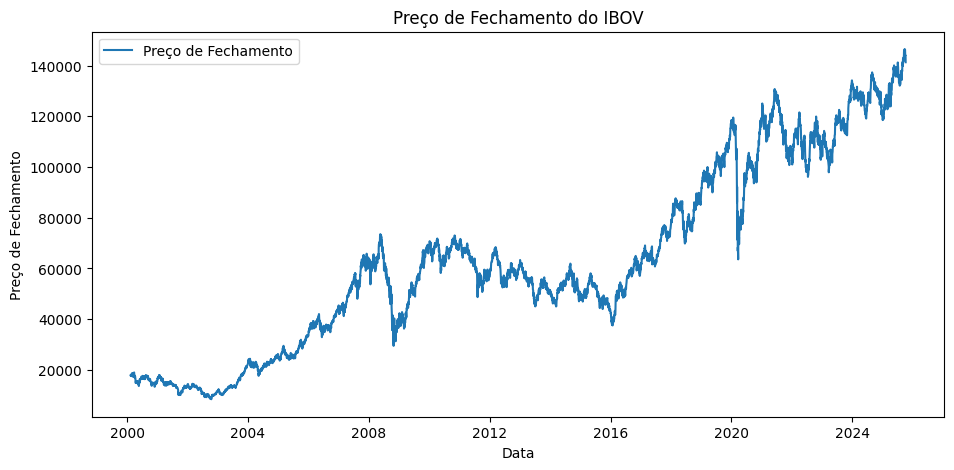

In [6]:
plt.figure(figsize=(11, 5))
plt.plot(ibov['Data'], ibov["Último"], label="Preço de Fechamento")
plt.title("Preço de Fechamento do IBOV")
plt.xlabel("Data")
plt.ylabel("Preço de Fechamento")
plt.legend()
plt.show()

## Seasonal Decompose e diferenciação

<Axes: >

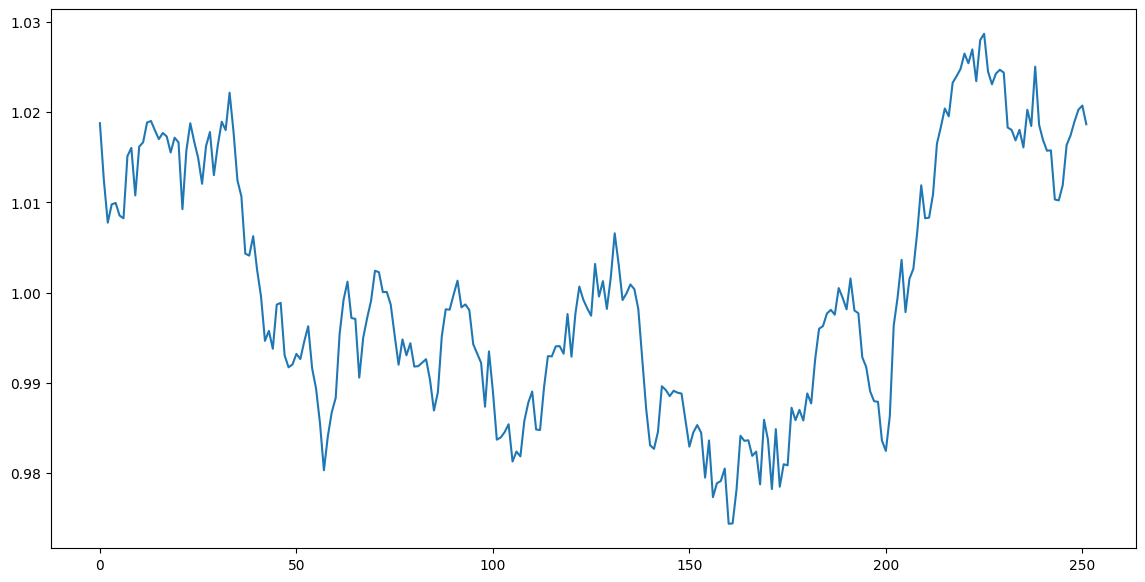

In [36]:
result = seasonal_decompose(ibov["Último"], model="multiplicative", period=252)
result.seasonal.iloc[:252].plot(figsize=(14, 7))

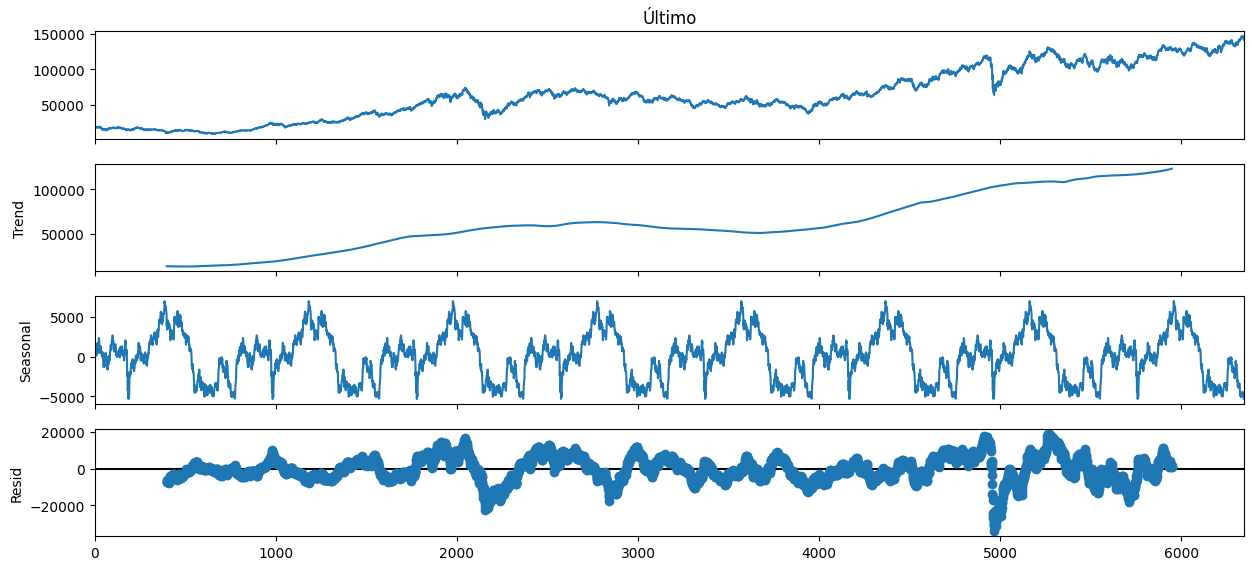

In [189]:
result = seasonal_decompose(ibov["Último"], model="additive", period=796)
fig = result.plot()
fig.set_size_inches(14, 6)

The ACF coefficients intercept the threshold at lag 536


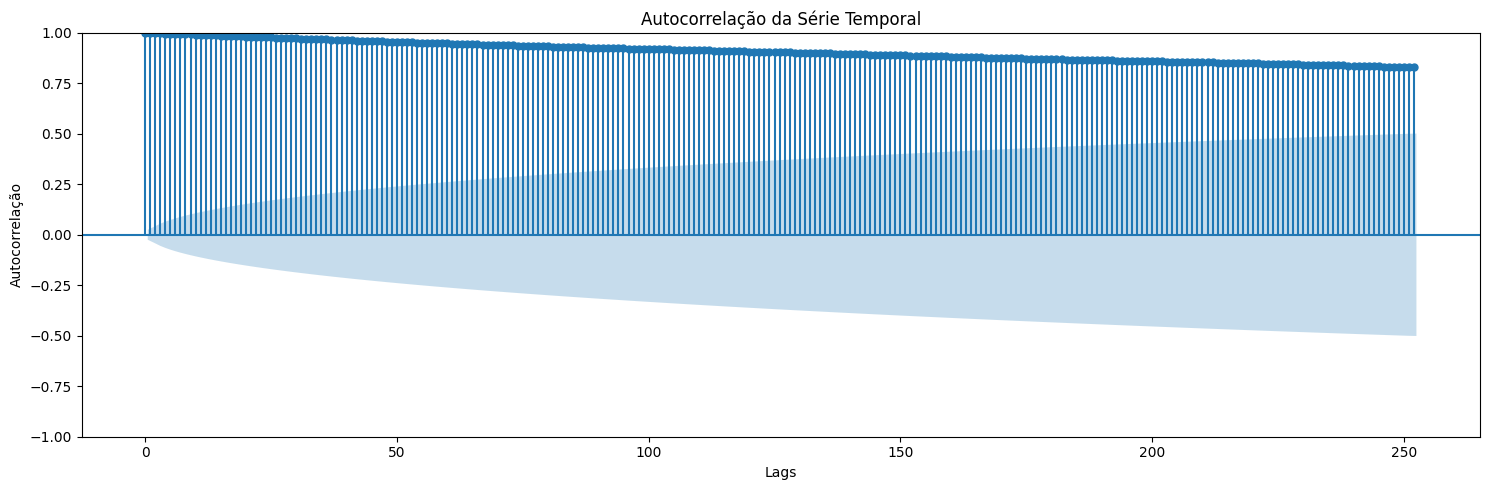

In [47]:
def plot_acf(data, lags=252, title="Autocorrelação da Série Temporal"):

    fig, ax = plt.subplots(figsize=(15, 5))
    # Get the ACF values and confidence intervals
    _plot_acf(data, lags=lags, ax=ax, alpha=0.05)
    ax.set_title(title)
    ax.set_xlabel("Lags")
    ax.set_ylabel("Autocorrelação")
    fig.set_tight_layout(True)

    acf_x = sm.tsa.acf(data, alpha=0.05, nlags=700)
    acf, ci = acf_x[:2]
    intercept_point = np.where(abs(acf) < (ci[:, 1] - acf))
    if intercept_point[0].size > 0:
        print(
            f"The ACF coefficients intercept the threshold at lag {intercept_point[0][0]}"
        )
    else:
        print("The ACF coefficients do not intercept the threshold")
        
plot_acf(ibov["Último"])

The PACF coefficients intercept the threshold at lag 2


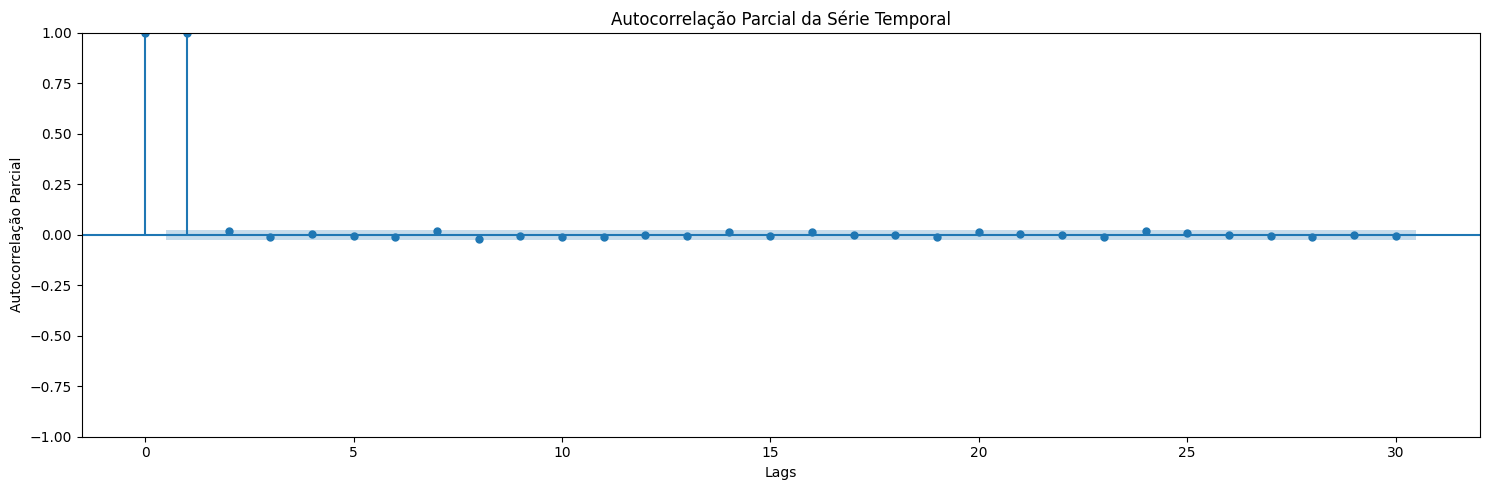

In [48]:
from statsmodels.graphics.tsaplots import plot_pacf as _plot_pacf

def plot_pacf(data, lags=30, title="Autocorrelação Parcial da Série Temporal"):

    fig, ax = plt.subplots(figsize=(15, 5))
    # Get the ACF values and confidence intervals
    _plot_pacf(data, lags=lags, ax=ax, alpha=0.05)
    ax.set_title(title)
    ax.set_xlabel("Lags")
    ax.set_ylabel("Autocorrelação Parcial")
    fig.set_tight_layout(True)

    acf_x = sm.tsa.pacf(data, alpha=0.05, nlags=lags)
    acf, ci = acf_x[:2]
    intercept_point = np.where(abs(acf) < (ci[:, 1] - acf))
    if intercept_point[0].size > 0:
        print(
            f"The PACF coefficients intercept the threshold at lag {intercept_point[0][0]}"
        )
    else:
        print("The PACF coefficients do not intercept the threshold")
        
plot_pacf(ibov["Último"])

In [21]:
adf_result = sm.tsa.adfuller(ibov["Último"])
print(f"ADF Statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")
print(f"Critical Values: {adf_result[4]}")

if adf_result[1] < 0.05:
    print("A série temporal é estacionária")
else:
    print("A série temporal não é estacionária")

ADF Statistic: -0.5325398622934598
p-value: 0.8855086272052622
Critical Values: {'1%': -3.431382831089674, '5%': -2.861996420816857, '10%': -2.567012949712604}
A série temporal não é estacionária


<Axes: >

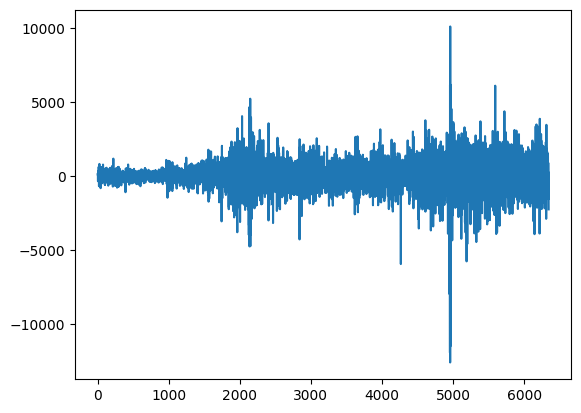

In [22]:
ibov["Último"].diff().plot()

In [23]:
adf_result = sm.tsa.adfuller(ibov["Último"].diff().dropna())
print(f"ADF Statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")
print(f"Critical Values: {adf_result[4]}")

if adf_result[1] < 0.05:
    print("A série temporal é estacionária")
else:
    print("A série temporal não é estacionária")

ADF Statistic: -22.162715970712785
p-value: 0.0
Critical Values: {'1%': -3.431382831089674, '5%': -2.861996420816857, '10%': -2.567012949712604}
A série temporal é estacionária


In [24]:
acf_x = sm.tsa.acf(ibov["Último"], alpha=0.05, nlags=1000)
acf, ci = acf_x[:2]

q = np.where(abs(acf) < (ci[:, 1] - acf))[0][0]

pacf_x = sm.tsa.pacf(ibov["Último"], alpha=0.05, nlags=30)
pacf, ci = pacf_x[:2]

p = np.where(abs(pacf) < (ci[:, 1] - pacf))[0][0]

d = 1
print(p, q, d)

2 536 1


In [53]:
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [54]:
model = pm.auto_arima(
    ibov["Último"],
    seasonal=True,
    m=12,
    stepwise=True,
)

print(model.summary())

seasonal_order = model.seasonal_order
print(f"Detected Seasonal Order: {seasonal_order}")

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 6346
Model:               SARIMAX(2, 1, 2)   Log Likelihood              -52979.426
Date:                Thu, 09 Oct 2025   AIC                         105968.852
Time:                        11:46:36   BIC                         106002.629
Sample:                             0   HQIC                        105980.548
                               - 6346                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.5325      0.038    -40.766      0.000      -1.606      -1.459
ar.L2         -0.7025      0.035    -20.076      0.000      -0.771      -0.634
ma.L1          1.4735      0.040     36.992      0.0

## Montagem de df treino e teste

In [ ]:
train_size = ibov.shape[0] - 90
train, test = ibov[:train_size], ibov[train_size:]
warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)
def create_features(df):
    df["Data"] = pd.to_datetime(df["Data"])
    df["year"] = df["Data"].dt.year
    df["month"] = df["Data"].dt.month
    df["day"] = df["Data"].dt.day
    df["dayofweek"] = df["Data"].dt.dayofweek
    df["delta1"] = df["Último"].diff().shift(-1)
    df["delta5"] = df["Último"].diff().shift(-5)
    df['Var%'] = df['Var%']
    df['Vol.'] = df['Vol.']
    df['Target'] = df['Target']
    df['Direção'] = df['Direção']
    for w in [3, 7, 14, 21, 30]: #Médias móveis
        df[f"mm_{w}"] = df[f"mm_{w}"]
    for w in [5, 10, 20]: #Volatilidade
        df[f"vol_{w}"] = df[f"vol_{w}"]
    df['dif_mm3'] = df['dif_mm3']
    df["daily_return"] = ((df["Último"] - df["Abertura"]) / df["Abertura"]).shift(-1)
    return df

train = create_features(train)
test = create_features(test)

FEATURES = ["year", "month", "day", "dayofweek", "Abertura", "delta1", "delta5", "daily_return", "Vol.", "mm_3", "mm_7", "mm_14", "mm_21", "mm_30", "vol_5", "vol_10", "vol_20", "dif_mm3"]
TARGET = ["Target"]

X_train, y_train = train[FEATURES], train[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]

train.head(5)

,Data,Último,Abertura,Máxima,Mínima,Vol.,Var%,Direção,mm_3,dif_mm3,...,Target,Var,delta,year,month,day,dayofweek,delta1,delta5,daily_return
0,2000-02-14,17819.0,18083.0,18264.0,17746.0,772930000.0,-1.46,0,18168.666667,-349.666667,...,1,264.0,18083.0,2000,2,14,0,NaN,NaN,NaN
1,2000-02-15,17921.0,17818.0,17932.0,17451.0,919500000.0,0.57,1,17941.000000,-20.000000,...,1,-103.0,17819.0,2000,2,15,1,NaN,NaN,-0.014599
2,2000-02-16,18112.0,17921.0,18247.0,17743.0,111360000.0,1.07,1,17950.666667,161.333333,...,0,-191.0,17921.0,2000,2,16,2,102.0,NaN,0.005781
3,2000-02-17,17979.0,18116.0,18297.0,17979.0,683210000.0,-0.73,0,18004.000000,-25.000000,...,0,137.0,18112.0,2000,2,17,3,191.0,NaN,0.010658
4,2000-02-18,17625.0,17979.0,18008.0,17489.0,733360000.0,-1.97,0,17905.333333,-280.333333,...,1,354.0,17979.0,2000,2,18,4,-133.0,NaN,-0.007562


# XGBoost

In [ ]:
#Regressor
reg = xgb.XGBRegressor(objective="reg:squarederror")
reg.fit(X_train, y_train)

#Classificador
clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
clf.fit(X_train, y_train)

preds_clf = clf.predict(X_test) 
metrics_xgb_clf = calculate_metrics(y_test, preds_clf)
print("XGBoost Classificador Metrics:")
print_metrics(metrics_xgb_clf)

preds_reg = reg.predict(X_test)
metrics_xgb_reg = calculate_metrics(y_test, preds_reg)
print("XGBoost Regressor Metrics:")
print_metrics(metrics_xgb_reg)

acc_xgb_clf = (y_test.reset_index(drop=True) == preds_clf).mean()
print(f"Acurácia Direcional XGBoost: {acc_xgb_clf:.2%}")

XGBoost Regressor Metrics:
MAE: 0.5198812484741211
MSE: 0.33523446321487427
MAPE: 130764171640832000.00 %


# Prophet

In [19]:
train_prophet = train.rename(columns={"Data": "ds", "Target": "y"})
test_prophet = test.rename(columns={"Data": "ds", "Target": "y"})

model = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=True, )
model.add_regressor("Direção")
model.fit(train_prophet)

future = model.make_future_dataframe(periods=len(test))
future["Direção"] = pd.concat([train["Direção"], test["Direção"]], ignore_index=True)
forecast = model.predict(future)

preds = forecast[["ds", "yhat"]].tail(len(test))
preds = preds.set_index("ds")
y_test = test_prophet.set_index("ds")["y"]

metrics_pr = calculate_metrics(y_test, preds["yhat"])
print("Prophet Metrics:")
print_metrics(metrics_pr)

pred_direction = (preds["yhat"] >= 0.5).astype(int).reset_index(drop=True)
real_direction = y_test.astype(int).reset_index(drop=True)

acc_proph = (real_direction == pred_direction).mean()

print(f"Acurácia Direcional Prophet: {acc_proph:.2%}")

17:54:25 - cmdstanpy - INFO - Chain [1] start processing
17:54:26 - cmdstanpy - INFO - Chain [1] done processing


Prophet Metrics:
MAE: 0.5041210624936164
MSE: 0.25751040914076645
MAPE: 131702218657488480.00 %
Acurácia Direcional Prophet: 50.00%


# SARIMAX

In [25]:
exog_train = train[["Direção"]]
exog_test = test[["Direção"]]

model = sm.tsa.statespace.SARIMAX(
    train["Target"],
    exog=exog_train,
    order=(
        p,
        d,
        1, # Diminuir o "q" para otimizar processamento
    ),  
    seasonal_order=(0, 0, 0, 12),
)
results = model.fit()

preds = results.get_forecast(steps=len(test), exog=exog_test).predicted_mean

metrics_sarimax = calculate_metrics(test["Target"], preds)
print("SARIMAX Metrics:")
print_metrics(metrics_sarimax)

acc_smx = (y_test.reset_index(drop=True) == preds_clf).mean()

print(f"Acurácia de direção: {acc_smx:.2%}")

SARIMAX Metrics:
MAE: 0.5022818778990863
MSE: 0.25310997101896515
MAPE: 126577930610857568.00 %
Acurácia de direção: 43.33%


# Resultados

In [116]:
pred_sarimax = preds
pred_prophet = forecast["yhat"].tail(len(test))
pred_xgboost = reg.predict(X_test)

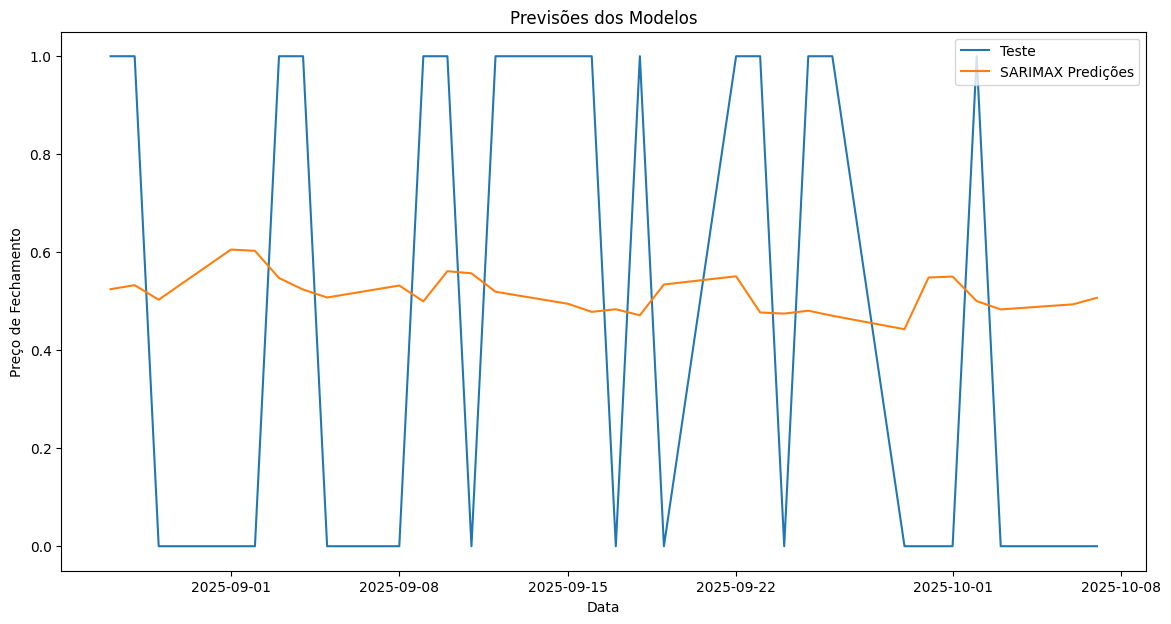

In [119]:
plt.figure(figsize=(14, 7))
plt.plot(test["Data"], test["Target"], label="Teste")
plt.plot(test["Data"], pred_sarimax, label="SARIMAX Predições")
#plt.plot(test["Data"], pred_xgboost, label="XGBoost Predições")
#plt.plot(test_prophet["ds"], pred_prophet, label="Prophet Predições")
plt.title("Previsões dos Modelos")
plt.xlabel("Data")
plt.ylabel("Preço de Fechamento")
#plt.ylim(bottom=125000)
plt.legend()

In [104]:
df = pd.DataFrame(
    [metrics_xgb_clf, metrics_pr, metrics_sarimax],
    columns=["MAE", "MSE", "MAPE"],
    index=["XGBoost", "Prophet", "SARIMAX"],
)
df.sort_values(by="MAPE", ascending=True).applymap(lambda x: f"{x:0.2f}" if isinstance(x, (int, float)) else x)

,MAE,MSE,MAPE
XGBoost,0.03,0.03,15011998757901654.00
SARIMAX,0.50,0.25,114631928655318304.00
Prophet,0.51,0.26,117482476170363568.00


In [59]:
x = ibov[["delta", "mm_14", "dif_mm3", "Var"]]
y = ibov["Target"]

train_size = ibov.shape[0] - 30

X_train = x[:train_size]
X_test = x[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("Base Treinamento \nSubiu:", list(y_train).count(1), " Desceu:", list(y_train).count(0), "\nBase Testes \nSubiu:", list(y_test).count(1), " Desceu:", list(y_test).count(0))


Base Treinamento 
Subiu: 3269  Desceu: 3047 
Base Testes 
Subiu: 15  Desceu: 15


Acurácia:46.67%

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.48      0.93      0.64        15
           1       0.00      0.00      0.00        15

    accuracy                           0.47        30
   macro avg       0.24      0.47      0.32        30
weighted avg       0.24      0.47      0.32        30

[[14  1]
 [15  0]]


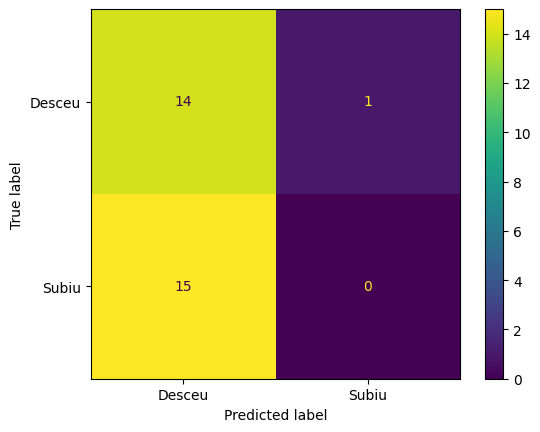

In [64]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=16,
    class_weight="balanced"
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

acuracia_rf = accuracy_score(y_test, y_pred)
print(f"Acurácia:{acuracia_rf*100:.2f}%")
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Desceu", "Subiu"])
disp.plot()
plt.show()

Acurácia Regressão Logística: 53.33%

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.53      0.60      0.56        15
           1       0.54      0.47      0.50        15

    accuracy                           0.53        30
   macro avg       0.53      0.53      0.53        30
weighted avg       0.53      0.53      0.53        30


Matriz de Confusão:
 [[9 6]
 [8 7]]


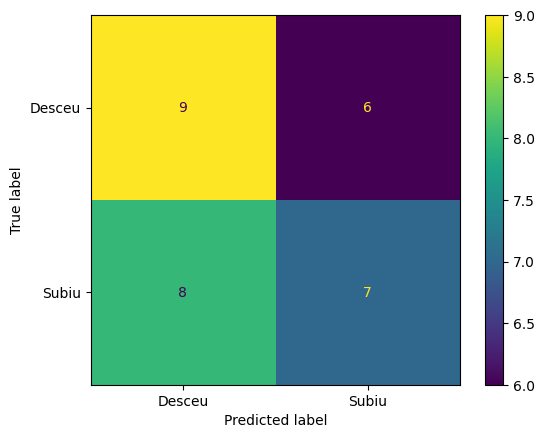

In [61]:
logreg = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)

acc_logreg = logreg.score(X_test, y_test)
print(f"Acurácia Regressão Logística: {acc_logreg*100:.2f}%")
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred))
print("\nMatriz de Confusão:\n", confusion_matrix(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Desceu", "Subiu"])
disp.plot()
plt.show()